In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_excel('../Data/Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [42]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12,4.15,12680.0,France,16.60
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12,4.95,12680.0,France,14.85


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [28]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [29]:
df.dropna(inplace=True)
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [30]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [32]:
#total Revenue
total_revenue = df["TotalPrice"].sum()
print(f"Total Revenue: {total_revenue}")

Total Revenue: 8911407.904


In [33]:
#total orders
total_orders = df["InvoiceNo"].nunique()
print(f"Total Orders: {total_orders}")

Total Orders: 18532


In [34]:
#average order value
average_order_value = total_revenue / total_orders
print(f"Average Order Value: {average_order_value}")

Average Order Value: 480.8659563997409


In [35]:
#top 10 customers by total spending
top_customers = df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False).head(10)
print("Top 10 Customers by Total Spending:")
print(top_customers)

Top 10 Customers by Total Spending:
CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalPrice, dtype: float64


In [36]:
#repeated customers
customer_order_counts = df.groupby("CustomerID")["InvoiceNo"].nunique()
repeated_customers = customer_order_counts[customer_order_counts > 1]
print("Repeated Customers:")
print(repeated_customers)

Repeated Customers:
CustomerID
12347.0     7
12348.0     4
12352.0     8
12356.0     3
12358.0     2
           ..
18272.0     6
18273.0     3
18282.0     2
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 2845, dtype: int64


In [37]:
#best-selling product
best_selling_product = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(1)
print("Best-Selling Product:")
print(best_selling_product)

Best-Selling Product:
Description
PAPER CRAFT , LITTLE BIRDIE    80995
Name: Quantity, dtype: int64


In [38]:
#highest revenue product
highest_revenue_product = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(1)
print("Highest Revenue Product:")   
print(highest_revenue_product)

Highest Revenue Product:
Description
PAPER CRAFT , LITTLE BIRDIE    168469.6
Name: TotalPrice, dtype: float64


In [68]:
#top countries by revenue
top_countries = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)
print("Top 10 Countries by Revenue:")
print(top_countries)

Top 10 Countries by Revenue:
Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: TotalPrice, dtype: float64


In [39]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='object')


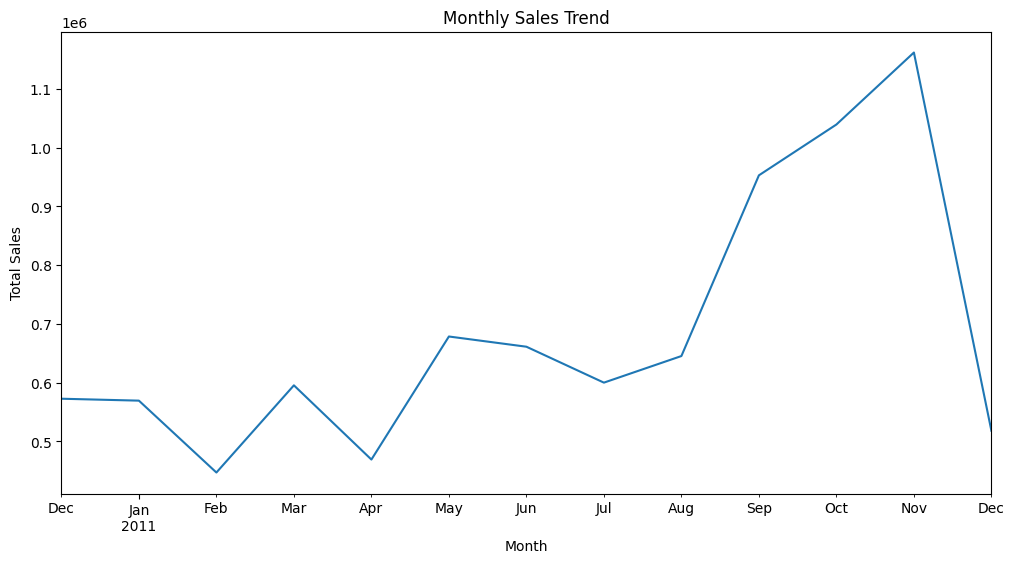

In [41]:
#monthly sales trend
df["InvoiceDate"] = df["InvoiceDate"].dt.to_period("M")
monthly_sales = df.groupby("InvoiceDate")["TotalPrice"].sum()
plt.figure(figsize=(12, 6))
plt.title("Monthly Sales Trend")
monthly_sales.plot()
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


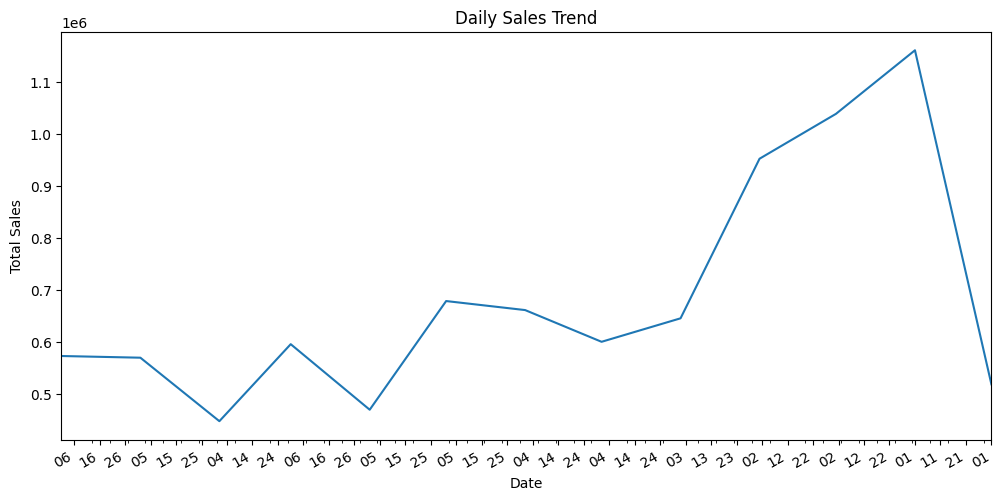

In [65]:
#daily sales trend
import matplotlib.dates as mdates


df["InvoiceDate"] = df["InvoiceDate"].dt.to_period("D")  # Convert to datetime without time component
daily_sales = df.groupby("InvoiceDate")["TotalPrice"].sum()
fig, ax = plt.subplots(figsize=(12, 6))
daily_sales.plot(ax=ax)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=10))  # Shows a tick every 5 days
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d"))  # Date format

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.gcf().autofmt_xdate()  # Rotates dates automatically so they do not overlap
plt.show()

<Axes: title={'center': 'Top 10 Products by Revenue'}, xlabel='Description', ylabel='Total Revenue'>

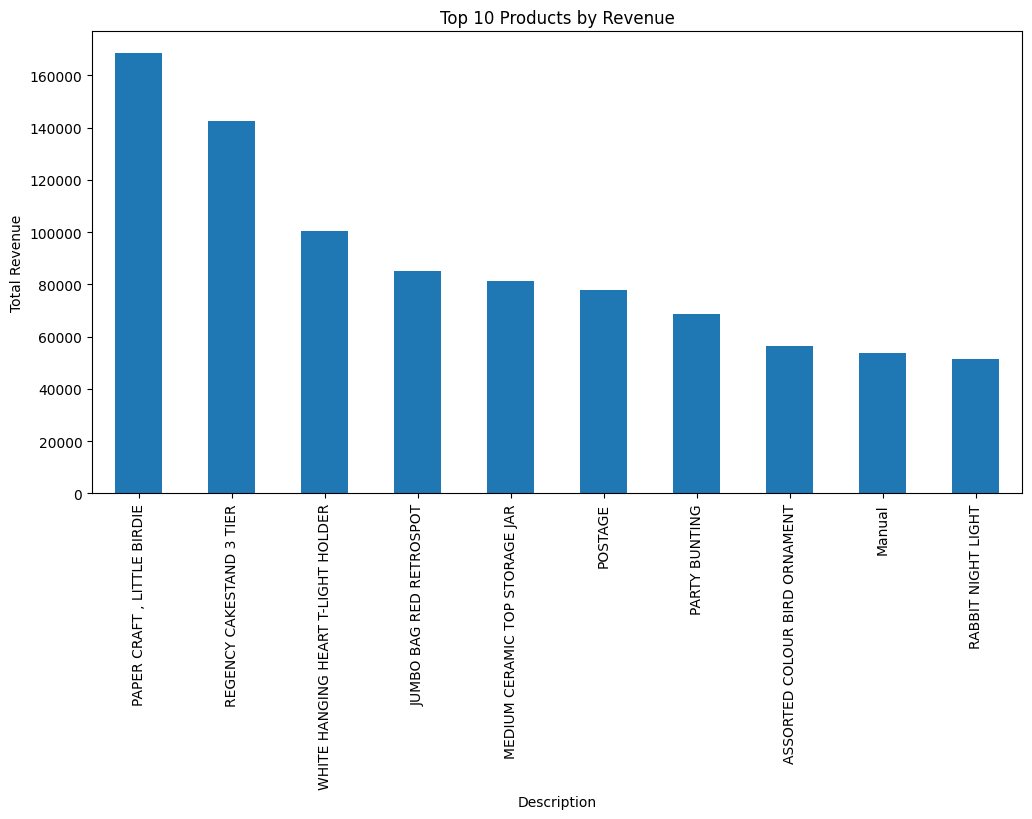

In [66]:
#top 10 products by revenue
top_products = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
top_products.plot(kind='bar')

<Axes: title={'center': 'Top 10 Countries by Revenue'}, xlabel='Country', ylabel='Total Revenue'>

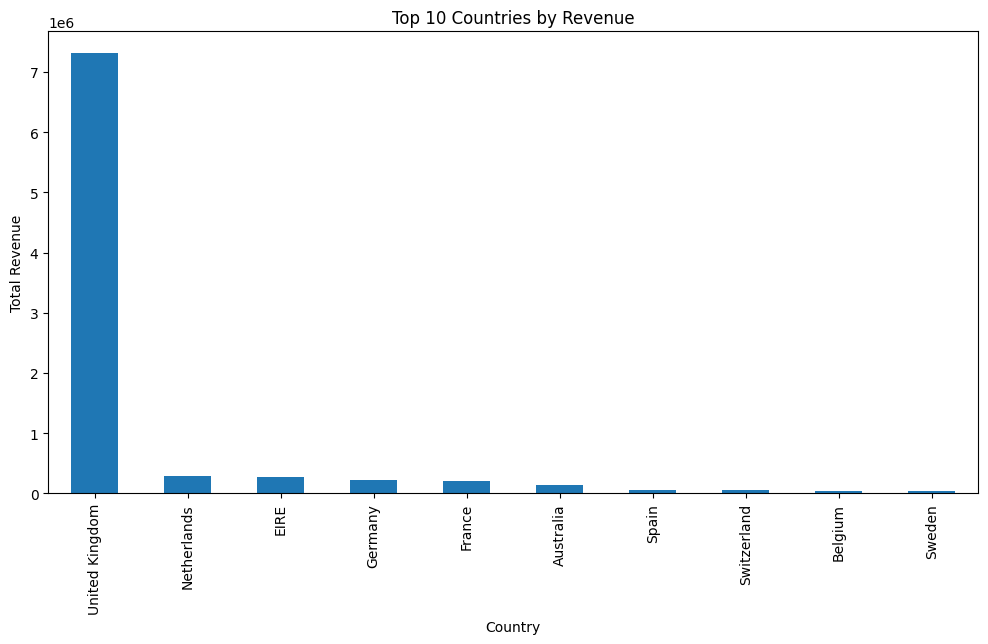

In [67]:
#top revenue by country
top_countries = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
top_countries.plot(kind='bar')